# 03c · How forecastable is this, really — and at what horizon?

Notebook `03b` ended with a one-line persistence baseline scoring **R² = 0.914** out of sample.
Taken at face value that reads as *problem solved, nothing left to model*. It is not, and this
notebook shows why by asking two questions the headline figure conceals.

**Question 1 — where does that variance actually come from?** A panel pools 600+ facilities of
wildly different size. A model that only knows *which* facility it is looking at already scores
well, without forecasting anything.

**Question 2 — how fast does skill decay with the forecast horizon?** Persistence is unbeatable
one step ahead and useless far out. The operational decisions this project exists to support —
hiring relief staff, opening surge beds, rescheduling shifts — need **4 to 8 weeks** of lead time.
Skill at a one-week horizon is the wrong thing to measure.

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd().parent))
from src.features.build_features import load_weekly_target

BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK_SOFT = "#0b0b0b", "#52514e"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": "#d5d4cf", "axes.linewidth": 0.8,
    "axes.grid": True, "grid.color": "#e8e7e2", "grid.linewidth": 0.6,
    "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "text.color": INK, "axes.labelcolor": INK_SOFT, "axes.titlecolor": INK,
    "xtick.color": INK_SOFT, "ytick.color": INK_SOFT,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "600", "figure.dpi": 110,
})

Y = "Total_Respiratorias"
# Full facility set here, not the pollution-linked subset used in 03b.
p = load_weekly_target(2022, 2025).sort_values(
    ["EstablecimientoCodigo", "Anio", "SemanaEstadistica"])
print(f"{len(p):,} facility-weeks · {p.EstablecimientoCodigo.nunique()} facilities · "
      f"{p.Anio.min()}-{p.Anio.max()}")

127,245 facility-weeks · 629 facilities · 2022-2025


## 1 · Variance decomposition — what is a panel R² actually rewarding?

Total variance splits three ways:

- **Between facilities** — a large hospital always outnumbers a rural SAPU. A facility ID gives
  this away for free; predicting it is not forecasting.
- **Seasonal within facility** — the winter cycle. A calendar gives this away for free too.
- **Anomaly** — the deviation from that facility's own normal for that week of the year. This, and
  only this, is the forecasting problem.

total variance 21,102

                    component     variance  share
between facilities (identity) 12689.743913   60.1
     seasonal within facility  4317.772195   20.5
           anomaly (the task)  2743.453194   13.0


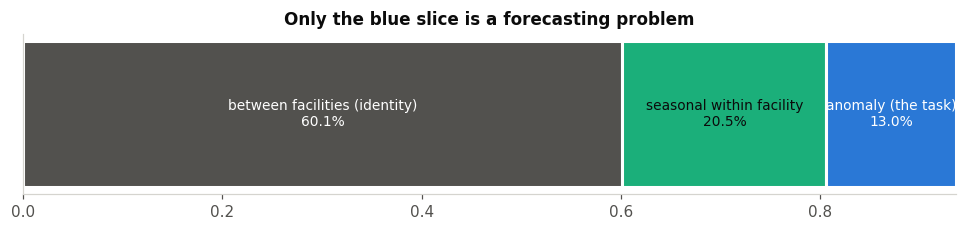

In [2]:
tot = p[Y].var()
fac_mean = p.groupby("EstablecimientoCodigo")[Y].transform("mean")
clim = p.groupby(["EstablecimientoCodigo", "SemanaEstadistica"])[Y].transform("mean")
p["within"] = p[Y] - fac_mean
p["anom"] = p[Y] - clim
seasonal = p["within"] - p["anom"]

parts = pd.DataFrame({
    "component": ["between facilities (identity)", "seasonal within facility", "anomaly (the task)"],
    "variance": [fac_mean.var(), seasonal.var(), p["anom"].var()],
})
parts["share"] = parts.variance / tot
print(f"total variance {tot:,.0f}\n")
print(parts.assign(share=lambda d: (d.share * 100).round(1)).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 2.2))
left = 0
for lbl, v, c in zip(parts.component, parts.share, [INK_SOFT, AQUA, BLUE]):
    ax.barh([0], [v], left=left, color=c, edgecolor="white", linewidth=2, height=0.5)
    ax.annotate(f"{lbl}\n{v:.1%}", (left + v / 2, 0), ha="center", va="center",
                fontsize=9, color="white" if c != AQUA else INK)
    left += v
ax.set_xlim(0, left); ax.set_yticks([]); ax.grid(False)
ax.set_title("Only the blue slice is a forecasting problem")
plt.tight_layout(); plt.show()

## 2 · Skill decay by horizon

Two baselines, fitted on 2022-2024 and scored on 2025:

- **Persistence** — predict this week from *h* weeks ago. Degrades as *h* grows.
- **Climatology** — predict this week from that facility's historical average for that week of the
  year. **Flat in h**: forecasting 12 weeks out costs it nothing extra.

Where those two lines cross is where persistence stops being the thing to beat.

 horizon_wk  persistence_R2  persistence_MAE  climatology_R2  climatology_MAE  persistence_R2_on_anomaly
          1          0.9199          24.2526          0.7741          39.2981                     0.5259
          2          0.8470          32.6866          0.7741          39.2981                     0.2791
          4          0.7093          46.0217          0.7741          39.2981                    -0.0691
          8          0.5157          61.4428          0.7741          39.2981                    -0.3022
         12          0.4005          68.2105          0.7741          39.2981                    -0.3202

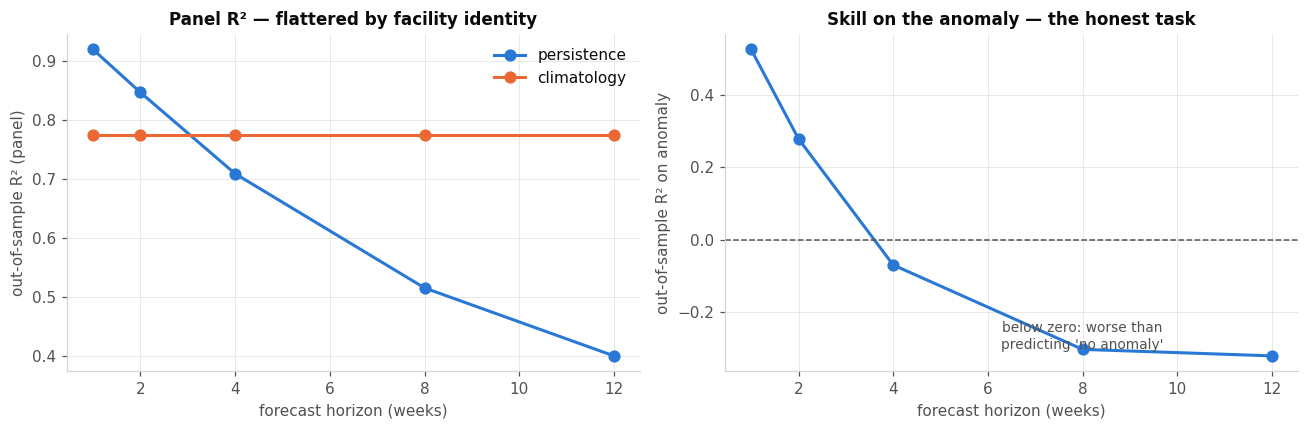


Persistence falls below climatology between weeks 2 and 4.
Persistence skill on the anomaly turns NEGATIVE from week 4 onward: at a month's
lead time, last month's deviation is worse than assuming no deviation at all.


In [3]:
train, test = p[p.Anio <= 2024], p[p.Anio == 2025].copy()
tr_clim = train.groupby(["EstablecimientoCodigo", "SemanaEstadistica"])[Y].mean()
tr_fac = train.groupby("EstablecimientoCodigo")[Y].mean()

test["clim"] = pd.MultiIndex.from_frame(
    test[["EstablecimientoCodigo", "SemanaEstadistica"]]).map(tr_clim)
test["clim"] = test["clim"].fillna(test.EstablecimientoCodigo.map(tr_fac))
test = test.dropna(subset=["clim"])
test["anom"] = test[Y] - test["clim"]

def score(actual, pred):
    m = ~(np.isnan(actual) | np.isnan(pred))
    a, q = np.asarray(actual)[m], np.asarray(pred)[m]
    return 1 - ((a - q) ** 2).sum() / ((a - a.mean()) ** 2).sum(), np.abs(a - q).mean()

g = test.groupby("EstablecimientoCodigo")
HORIZONS = [1, 2, 4, 8, 12]
rows = []
for h in HORIZONS:
    r2p, maep = score(test[Y], g[Y].shift(h))
    r2c, maec = score(test[Y], test["clim"])
    r2pa, _ = score(test["anom"], g["anom"].shift(h))
    rows.append({"horizon_wk": h, "persistence_R2": r2p, "persistence_MAE": maep,
                 "climatology_R2": r2c, "climatology_MAE": maec,
                 "persistence_R2_on_anomaly": r2pa})
res = pd.DataFrame(rows)
print(res.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax = axes[0]
ax.plot(res.horizon_wk, res.persistence_R2, marker="o", markersize=7, color=BLUE,
        linewidth=2, label="persistence")
ax.plot(res.horizon_wk, res.climatology_R2, marker="o", markersize=7, color=ORANGE,
        linewidth=2, label="climatology")
ax.set_xlabel("forecast horizon (weeks)"); ax.set_ylabel("out-of-sample R² (panel)")
ax.set_title("Panel R² — flattered by facility identity")
ax.legend(frameon=False)

ax = axes[1]
ax.plot(res.horizon_wk, res.persistence_R2_on_anomaly, marker="o", markersize=7,
        color=BLUE, linewidth=2)
ax.axhline(0, color=INK_SOFT, linewidth=1, linestyle="--")
ax.set_xlabel("forecast horizon (weeks)"); ax.set_ylabel("out-of-sample R² on anomaly")
ax.set_title("Skill on the anomaly — the honest task")
ax.annotate("below zero: worse than\npredicting 'no anomaly'", (8, -0.3),
            fontsize=9, color=INK_SOFT, ha="center")
plt.tight_layout(); plt.show()

cross = res[res.persistence_R2 < res.climatology_R2].horizon_wk.min()
print(f"\nPersistence falls below climatology between weeks 2 and {cross}.")
print("Persistence skill on the anomaly turns NEGATIVE from week 4 onward: at a month's")
print("lead time, last month's deviation is worse than assuming no deviation at all.")

## 3 · The operational metric — do we catch a surge in time?

R² is not what a hospital administrator consumes. The decision is binary: *is an unusually heavy
week coming, yes or no?* A surge is defined here as a week above that facility's **own** 90th
percentile of historical demand — a relative definition, so a rural SAPU and a regional hospital are
each judged against their own normal.

surge weeks in the 2025 test set: 7.7% of facility-weeks

                predictor  recall  precision
climatology (any horizon)   0.125      0.189
        persistence h=1wk   0.531      0.532
        persistence h=2wk   0.424      0.427
        persistence h=4wk   0.297      0.305
        persistence h=8wk   0.194      0.228


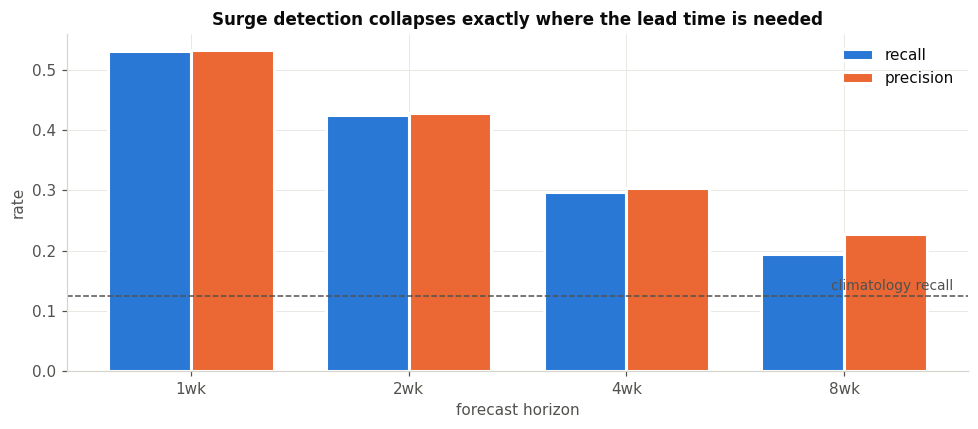

In [4]:
thr = train.groupby("EstablecimientoCodigo")[Y].quantile(0.9)
test["is_surge"] = test[Y] > test.EstablecimientoCodigo.map(thr)
print(f"surge weeks in the 2025 test set: {test.is_surge.mean():.1%} of facility-weeks\n")

def pr(pred, truth):
    m = pred.notna() & truth.notna()
    tp = (pred[m] & truth[m]).sum(); fp = (pred[m] & ~truth[m]).sum(); fn = (~pred[m] & truth[m]).sum()
    return (tp / (tp + fn) if tp + fn else np.nan), (tp / (tp + fp) if tp + fp else np.nan)

thr_map = test.EstablecimientoCodigo.map(thr)
rows = [{"predictor": "climatology (any horizon)",
         **dict(zip(["recall", "precision"], pr(test["clim"] > thr_map, test.is_surge)))}]
for h in (1, 2, 4, 8):
    rec, prec = pr(g[Y].shift(h) > thr_map, test.is_surge)
    rows.append({"predictor": f"persistence h={h}wk", "recall": rec, "precision": prec})
alerts = pd.DataFrame(rows)
print(alerts.round(3).to_string(index=False))

sub = alerts[alerts.predictor.str.startswith("persistence")]
fig, ax = plt.subplots(figsize=(9, 4))
xs = np.arange(len(sub)); w = 0.38
ax.bar(xs - w/2, sub.recall, w, label="recall", color=BLUE, edgecolor="white", linewidth=2)
ax.bar(xs + w/2, sub.precision, w, label="precision", color=ORANGE, edgecolor="white", linewidth=2)
ax.axhline(alerts.recall.iloc[0], color=INK_SOFT, linestyle="--", linewidth=1)
ax.annotate("climatology recall", (len(sub) - 0.5, alerts.recall.iloc[0]),
            textcoords="offset points", xytext=(0, 4), ha="right", fontsize=9, color=INK_SOFT)
ax.set_xticks(xs); ax.set_xticklabels([f"{h}wk" for h in (1, 2, 4, 8)])
ax.set_xlabel("forecast horizon"); ax.set_ylabel("rate")
ax.set_title("Surge detection collapses exactly where the lead time is needed")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

## 4 · Verdict

**The one-week R² of 0.92 is 60% facility identity and 20% calendar.** The forecasting problem is
the remaining 13% of variance, and measured on that alone, skill is far lower than the headline
suggests.

**At the horizons that matter operationally, nothing currently works.** From week 4 onward,
persistence on the anomaly is *negative* — worse than assuming no anomaly. Climatology holds a flat
R² of 0.774 on the panel but detects only 12.5% of surge weeks at 18.9% precision, because it
predicts the average winter and is blind to whether *this* winter is early, late, or severe.
Persistence at an 8-week horizon catches 19.4% of surges with 22.8% precision: four false alarms in
every five.

**So the project has a real target.** Not "pollution predicts demand" — that was tested in `03b`
and is worth under half a percentage point of R². The unmet need is **4-to-8-week-ahead surge
warning**, where the current best practice is close to guessing.

**The mechanism worth pursuing is epidemic, not environmental.** The anomaly is driven by viral wave
timing, and waves propagate across space: one comuna ignites before its neighbour. A per-facility
persistence model is blind to this by construction — it only ever looks at its own past. A model
that pools across facilities can see it. That is also the first *measured* justification for the
HDBSCAN clustering step, which until now was a plan item without evidence behind it.

**The honest risk.** Epidemic onset timing carries genuine stochasticity. It is entirely possible
that a large share of this anomaly is irreducible and that a TFT will not beat climatology either.
The next test — whether a facility's anomaly leads its neighbours' anomalies — is designed to find
that out cheaply, before any GPU time is committed.